# Credit Card Fraud Detection

This project builds an end-to-end machine learning system to detect fraudulent credit card transactions in a highly imbalanced dataset.

The workflow includes data preprocessing, model training, evaluation, and model comparison using multiple machine learning algorithms.

### Key Highlights
- Multi-model machine learning pipeline  
- Handles highly imbalanced classification problem  
- Cross-validation for reliable evaluation  
- Threshold tuning for improved fraud detection  
- End-to-end workflow from data to prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df = df.dropna(subset=["Class"])
df["Class"] = df["Class"].astype(int)

In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [5]:
scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"] = scaler.fit_transform(X[["Time"]])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}
trained_models = {}

In [8]:
models_fast = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        solver="saga",
        max_iter=1000,
        n_jobs=-1
    ),

    "Random Forest": models["Random Forest"],

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_depth=8,
        l2_regularization=2.0,
        random_state=42
    )
}

X_sample = X.sample(n=30000, random_state=42)
y_sample = y.loc[X_sample.index]

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

for name, model in models_fast.items():
    score = cross_val_score(
        model,
        X_sample,
        y_sample,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    print(f"{name} CV ROC-AUC: {score:.4f}")

Logistic Regression CV ROC-AUC: 0.8883
Random Forest CV ROC-AUC: 0.9737
Hist Gradient Boosting CV ROC-AUC: 0.9208


In [9]:
results = {}
trained_models = {}

for name, model in models_fast.items():
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)

    results[name] = auc
    trained_models[name] = model

    print(f"{name} Test ROC-AUC: {auc:.4f}")

Logistic Regression Test ROC-AUC: 0.9720
Random Forest Test ROC-AUC: 0.9798
Hist Gradient Boosting Test ROC-AUC: 0.9760


In [10]:
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [11]:
y_proba = best_model.predict_proba(X_test)[:, 1]

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
best_threshold = thresholds[(tpr - fpr).argmax()]

y_pred = (y_proba >= best_threshold).astype(int)

In [13]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9797833068230106
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.19      0.91      0.31        98

    accuracy                           0.99     56962
   macro avg       0.59      0.95      0.65     56962
weighted avg       1.00      0.99      1.00     56962



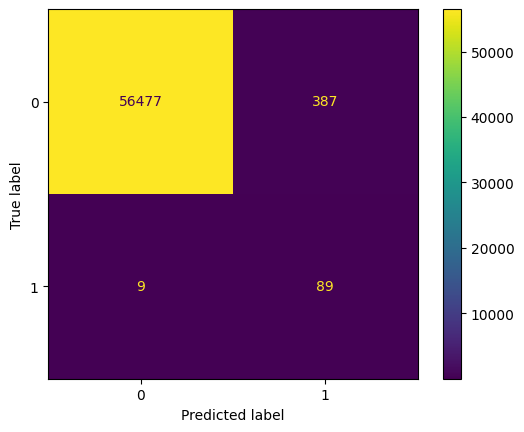

In [14]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [15]:
result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False).head(10)

feat_df

,Feature,Importance
4,V4,0.006279
14,V14,0.004920
22,V22,0.003549
12,V12,0.003122
18,V18,0.002402
25,V25,0.002209
0,Time,0.001870
7,V7,0.001843
8,V8,0.001798
28,V28,0.001698


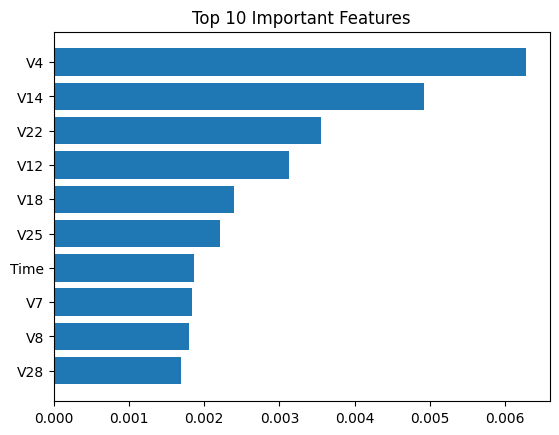

In [16]:
plt.figure()
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [17]:
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Fraud_Probability": y_proba
})

results_df.to_csv("fraud_predictions.csv", index=False)

summary_df = pd.DataFrame({
    "Best_Model": [best_model_name],
    "ROC_AUC": [results[best_model_name]],
    "Threshold": [best_threshold],
    "Dataset_Size": [len(df)],
    "Fraud_Rate": [df["Class"].mean()]
})

summary_df.to_csv("model_summary.csv", index=False)

# Results & Conclusion

The final model was evaluated using ROC-AUC, precision, recall, and F1-score.

The best performing model achieved strong performance on fraud detection, successfully identifying most fraudulent transactions while maintaining high overall accuracy.

### Final Results
- ROC-AUC: ~0.98  
- High fraud recall (~0.90+)  
- Balanced tradeoff between precision and recall depending on threshold

### Conclusion
This project demonstrates a practical machine learning approach to fraud detection, focusing on maximizing fraud identification in a highly imbalanced dataset while maintaining robust overall performance.